# ============================================================
# PART 1: CPCB Ground Data Preprocessing
# ============================================================

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [8]:
df = pd.read_csv("data_set.csv")

In [9]:
print("Shape:", df.shape)
print(df.dtypes)
print(df.isnull().sum())

Shape: (3376, 11)
country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    240
pollutant_max    240
pollutant_avg    240
dtype: int64


In [10]:
df.replace("NA", np.nan, inplace=True)

In [11]:
# Cast numeric columns
num_cols = ["pollutant_min", "pollutant_max", "pollutant_avg",
            "latitude", "longitude"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Parse timestamp
df["last_update"] = pd.to_datetime(df["last_update"],
                                   format="%d-%m-%Y %H:%M:%S",
                                   errors="coerce")

# Drop rows where avg value is missing (target variable)
df.dropna(subset=["pollutant_avg"], inplace=True)

print("After cleaning:", df.shape)

After cleaning: (3136, 11)


In [12]:
# ── 1.2  Pivot: one row per (station × timestamp) ──────────
# Each pollutant becomes its own column
pivot = df.pivot_table(
    index=["station", "city", "state",
           "latitude", "longitude", "last_update"],
    columns="pollutant_id",
    values="pollutant_avg",
    aggfunc="mean"
).reset_index()

pivot.columns.name = None          # remove "pollutant_id" axis name

# Standardise column names
pivot.rename(columns={
    "PM2.5": "PM25",
    "OZONE": "O3"
}, inplace=True)

print("Pivot shape:", pivot.shape)
print(pivot.head(3))


Pivot shape: (498, 13)
                                           station       city          state  \
0          Indira Nagar, Raebareli - NTPC Unchahar  Raebareli  Uttar_Pradesh   
1  15th Mile-Nongthymmai, Byrnihat - Meghalaya PCB   Byrnihat      Meghalaya   
2                       32Bungalows, Bhilai - CECB     Bhilai   Chhattisgarh   

    latitude  longitude         last_update    CO  NH3   NO2    O3   PM10  \
0  26.207781  81.245571 2026-06-11 15:00:00  28.0  9.0  19.0  83.0   68.0   
1  26.053740  91.867960 2026-06-11 15:00:00   4.0  NaN   2.0   NaN  151.0   
2  21.194815  81.314770 2026-06-11 15:00:00  10.0  3.0  12.0  52.0   20.0   

    PM25   SO2  
0   61.0  13.0  
1  205.0   NaN  
2   17.0  10.0  


In [13]:
pivot.sort_values(["station", "last_update"], inplace=True)
pivot.reset_index(drop=True, inplace=True)

In [14]:
# ── 1.4  Fill missing pollutant values ─────────────────────
pollutants = ["PM25", "PM10", "NO2", "SO2", "CO", "O3", "NH3", "NOx"]
pollutants = [p for p in pollutants if p in pivot.columns]

In [15]:
# Forward-fill within each station, then back-fill residuals
pivot[pollutants] = (
    pivot.groupby("station")[pollutants]
    .transform(lambda x: x.ffill().bfill())
)

# Any remaining NaN → column median
for col in pollutants:
    pivot[col].fillna(pivot[col].median(), inplace=True)

/tmp/ipykernel_1020/108136569.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pivot[col].fillna(pivot[col].median(), inplace=True)


In [16]:
# ── 1.5  Encode categorical location features ───────────────
le_state = LabelEncoder()
le_city  = LabelEncoder()

pivot["state_enc"] = le_state.fit_transform(pivot["state"])
pivot["city_enc"]  = le_city.fit_transform(pivot["city"])

In [17]:
# ── 1.6  Save cleaned ground data ──────────────────────────
pivot.to_csv("cpcb_cleaned.csv", index=False)
print("Saved → cpcb_cleaned.csv")

Saved → cpcb_cleaned.csv


# ============================================================
# PART 2: Google Earth Engine — Satellite Feature Extraction
# ============================================================
# Run this ONCE to export per-station daily satellite values.
# Outputs land in Google Drive as CSV files.
# ============================================================

In [18]:
import ee
import geemap
import pandas as pd

In [19]:
ee.Authenticate()

In [20]:
ee.Initialize(project='isro-bah-500813')

In [21]:

# ── 2.1  Station list from cleaned ground data ──────────────
ground = pd.read_csv("cpcb_cleaned.csv")

stations = (
    ground[["station", "latitude", "longitude"]]
    .drop_duplicates()
    .dropna()
    .reset_index(drop=True)
)

# Build an EE FeatureCollection of monitoring stations
features = [
    ee.Feature(
        ee.Geometry.Point([row.longitude, row.latitude]),
        {"station": row.station}
    )
    for _, row in stations.iterrows()
]
station_fc = ee.FeatureCollection(features)

In [22]:
# ── 2.2  Dataset registry (reuse from your existing code) ───
START_DATE = "2025-01-01"
END_DATE   = "2025-12-31"

In [23]:
DATASETS = {
    "NO2":         ("COPERNICUS/S5P/OFFL/L3_NO2",
                    "tropospheric_NO2_column_number_density", 1113),
    "SO2":         ("COPERNICUS/S5P/OFFL/L3_SO2",
                    "SO2_column_number_density",              1113),
    "CO":          ("COPERNICUS/S5P/OFFL/L3_CO",
                    "CO_column_number_density",               1113),
    "O3":          ("COPERNICUS/S5P/OFFL/L3_O3",
                    "O3_column_number_density",               1113),
    "HCHO":        ("COPERNICUS/S5P/OFFL/L3_HCHO",
                    "tropospheric_HCHO_column_number_density",1113),
    "AOD":         ("MODIS/061/MCD19A2_GRANULES",
                    "Optical_Depth_055",                      1000),
    "Temperature": ("ECMWF/ERA5_LAND/HOURLY",
                    "temperature_2m",                        11132),
    "Wind_U":      ("ECMWF/ERA5_LAND/HOURLY",
                    "u_component_of_wind_10m",               11132),
    "Wind_V":      ("ECMWF/ERA5_LAND/HOURLY",
                    "v_component_of_wind_10m",               11132),
    "Precipitation":("ECMWF/ERA5_LAND/HOURLY",
                    "total_precipitation",                   11132),
    "SurfacePressure":("ECMWF/ERA5_LAND/HOURLY",
                    "surface_pressure",                      11132),
}

In [24]:

# ── 2.3  Extract function: sample each image at stations ────
def extract_feature(name, collection_id, band, scale):
    """
    For each image in the collection, sample the band value
    at every monitoring station. Returns an EE table.
    """
    collection = (
        ee.ImageCollection(collection_id)
        .filterDate(START_DATE, END_DATE)
        .select(band)
    )

    def sample_image(image):
        date = image.date().format("YYYY-MM-dd")
        sampled = image.reduceRegions(
            collection=station_fc,
            reducer=ee.Reducer.mean(),
            scale=scale
        )
        return sampled.map(
            lambda f: f.set("date", date).set("variable", name)
        )

    return collection.map(sample_image).flatten()

In [25]:
# ── 2.4  Export each variable to Drive ─────────────────────
for var_name, (cid, band, scale) in DATASETS.items():

    table = extract_feature(var_name, cid, band, scale)

    task = ee.batch.Export.table.toDrive(
        collection=table,
        description=f"satellite_{var_name}",
        folder="AQI_Satellite_Data",
        fileNamePrefix=f"satellite_{var_name}",
        fileFormat="CSV",
        selectors=["station", "date", "mean"]
    )
    task.start()
    print(f"Export started → satellite_{var_name}.csv")

/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


Export started → satellite_NO2.csv
Export started → satellite_SO2.csv
Export started → satellite_CO.csv
Export started → satellite_O3.csv
Export started → satellite_HCHO.csv
Export started → satellite_AOD.csv
Export started → satellite_Temperature.csv
Export started → satellite_Wind_U.csv
Export started → satellite_Wind_V.csv
Export started → satellite_Precipitation.csv
Export started → satellite_SurfacePressure.csv


In [26]:
# ── 2.5  (After export) Merge all satellite CSVs ───────────
# Run this block after Drive exports are complete
import glob, os

def merge_satellite_exports(folder="AQI_Satellite_Data"):
    """
    Reads exported CSVs from Drive (downloaded locally),
    pivots variable → column, merges into one wide table.
    """
    dfs = []
    for fpath in glob.glob(os.path.join(folder, "satellite_*.csv")):
        var = os.path.basename(fpath).replace("satellite_","").replace(".csv","")
        tmp = pd.read_csv(fpath)[["station", "date", "mean"]]
        tmp.rename(columns={"mean": var}, inplace=True)
        dfs.append(tmp)

    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d, on=["station", "date"], how="outer")

    merged["date"] = pd.to_datetime(merged["date"])
    merged.sort_values(["station", "date"], inplace=True)
    merged.to_csv("satellite_merged.csv", index=False)
    print("Saved → satellite_merged.csv  shape:", merged.shape)
    return merged

# satellite_df = merge_satellite_exports()

# ============================================================
# PART 3: Feature Engineering & Final Dataset Assembly
# ============================================================

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import joblib
import os

In [28]:
# ── 3.1  Load ground data only ─────────────────────────────
ground = pd.read_csv("cpcb_cleaned.csv", parse_dates=["last_update"])
ground["date"] = ground["last_update"].dt.normalize()

In [29]:
# ── 3.2  Merge satellite data ONLY if it exists ─────────────
SAT_PATH = "satellite_merged.csv"

if os.path.exists(SAT_PATH):
    sat = pd.read_csv(SAT_PATH, parse_dates=["date"])
    df  = ground.merge(sat, on=["station", "date"], how="left")
    print("Satellite data merged.  Shape:", df.shape)
else:
    df = ground.copy()
    print("WARNING: satellite_merged.csv not found.")
    print("Proceeding with CPCB ground data only.")
    print("Run Part 2 (GEE export) and download CSVs to add satellite features.")

Proceeding with CPCB ground data only.
Run Part 2 (GEE export) and download CSVs to add satellite features.


In [30]:
# ── 3.3  Encode categoricals ────────────────────────────────
le_state = LabelEncoder()
le_city  = LabelEncoder()
df["state_enc"] = le_state.fit_transform(df["state"].astype(str))
df["city_enc"]  = le_city.fit_transform(df["city"].astype(str))

joblib.dump(le_state, "le_state.pkl")
joblib.dump(le_city,  "le_city.pkl")

['le_city.pkl']

In [31]:
# ── 3.4  Temporal features ──────────────────────────────────
df["month"]     = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear
df["dayofweek"] = df["date"].dt.dayofweek

df["month_sin"] = np.sin(2 * np.pi * df["month"]     / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]     / 12)
df["doy_sin"]   = np.sin(2 * np.pi * df["dayofyear"] / 365)
df["doy_cos"]   = np.cos(2 * np.pi * df["dayofyear"] / 365)
df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)

In [32]:
# ── 3.5  AQI Calculation (India CPCB standard) ─────────────
BREAKPOINTS = {
    "PM25":  [(0,30,0,50),(30,60,51,100),(60,90,101,200),
              (90,120,201,300),(120,250,301,400),(250,500,401,500)],
    "PM10":  [(0,50,0,50),(50,100,51,100),(100,250,101,200),
              (250,350,201,300),(350,430,301,400),(430,600,401,500)],
    "NO2":   [(0,40,0,50),(40,80,51,100),(80,180,101,200),
              (180,280,201,300),(280,400,301,400),(400,800,401,500)],
    "SO2":   [(0,40,0,50),(40,80,51,100),(80,380,101,200),
              (380,800,201,300),(800,1600,301,400),(1600,2100,401,500)],
    "CO":    [(0,1,0,50),(1,2,51,100),(2,10,101,200),
              (10,17,201,300),(17,34,301,400),(34,50,401,500)],
    "O3":    [(0,50,0,50),(50,100,51,100),(100,168,101,200),
              (168,208,201,300),(208,748,301,400),(748,1000,401,500)],
    "NH3":   [(0,200,0,50),(200,400,51,100),(400,800,101,200),
              (800,1200,201,300),(1200,1800,301,400),(1800,2400,401,500)],
}

def sub_index(concentration, breakpoints):
    for (cl, ch, il, ih) in breakpoints:
        if cl <= concentration <= ch:
            return il + (ih - il) * (concentration - cl) / (ch - cl)
    return 500

def compute_aqi(row):
    sub_indices = []
    for poll, bps in BREAKPOINTS.items():
        if poll in row.index and pd.notna(row[poll]):
            sub_indices.append(sub_index(float(row[poll]), bps))
    return max(sub_indices) if sub_indices else np.nan

df["AQI"] = df.apply(compute_aqi, axis=1)
df.dropna(subset=["AQI"], inplace=True)
print("AQI computed.  Non-null rows:", len(df))
print(df["AQI"].describe())

AQI computed.  Non-null rows: 498
count    498.000000
mean     353.687319
std       96.023126
min       75.500000
25%      301.201923
50%      347.588235
75%      425.750000
max      500.000000
Name: AQI, dtype: float64


In [33]:
# ── 3.6  Define feature columns dynamically ─────────────────
# Satellite features — only include columns that actually exist
SAT_FEATURES = ["NO2", "SO2", "CO", "O3", "HCHO", "AOD",
                "Temperature", "wind_speed", "wind_dir",
                "Precipitation", "SurfacePressure"]

# Ground pollutant features (use as proxy when satellite absent)
GROUND_POLL  = ["PM25", "PM10", "NO2", "SO2", "CO", "O3", "NH3"]

TEMPORAL_FEATURES = ["month_sin", "month_cos",
                     "doy_sin",   "doy_cos",
                     "dow_sin",   "dow_cos"]

SPATIAL_FEATURES  = ["latitude", "longitude",
                     "state_enc", "city_enc"]

# Pick whichever columns are present
sat_cols    = [c for c in SAT_FEATURES  if c in df.columns]
ground_cols = [c for c in GROUND_POLL   if c in df.columns]

# De-duplicate (satellite may already have NO2/SO2/CO/O3)
sat_only = [c for c in sat_cols if c not in ground_cols]

ALL_FEATURES = ground_cols + sat_only + TEMPORAL_FEATURES + SPATIAL_FEATURES
ALL_FEATURES = [c for c in ALL_FEATURES if c in df.columns]  # final safety

TARGET = "AQI"
print(f"\nUsing {len(ALL_FEATURES)} features:")
print(ALL_FEATURES)


Using 17 features:
['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'NH3', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'latitude', 'longitude', 'state_enc', 'city_enc']


In [34]:
# ── 3.7  Drop rows with NaN in features or target ───────────
keep_cols = ALL_FEATURES + [TARGET, "station", "date"]
df_model  = df[keep_cols].dropna()
print("Model-ready rows:", len(df_model))

if len(df_model) == 0:
    raise ValueError(
        "No rows left after dropna. Check that pollutant columns "
        "survived the pivot in Part 1 (cpcb_cleaned.csv)."
    )

Model-ready rows: 498


In [35]:
# ── 3.8  Normalise ──────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df_model = df_model.copy()
df_model[ALL_FEATURES] = scaler_X.fit_transform(df_model[ALL_FEATURES])
df_model[[TARGET]]     = scaler_y.fit_transform(df_model[[TARGET]])

joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

# Save feature list so Part 4 picks it up automatically
with open("feature_cols.txt", "w") as f:
    f.write("\n".join(ALL_FEATURES))

df_model.to_csv("model_input.csv", index=False)
print("\nSaved → model_input.csv")
print("Saved → scaler_X.pkl, scaler_y.pkl, feature_cols.txt")


Saved → model_input.csv
Saved → scaler_X.pkl, scaler_y.pkl, feature_cols.txt


# ============================================================
# PART 4: Sequence Construction + CNN-LSTM Model
# ============================================================

In [36]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.model_selection import train_test_split

In [37]:
SEQUENCE_LEN = 1  # Changed from 7 to 0 to prevent ValueError with current data
BATCH_SIZE   = 64
EPOCHS       = 100

In [38]:
# ── 4.1  Load data & feature list ──────────────────────────
df = pd.read_csv("model_input.csv", parse_dates=["date"])
df.sort_values(["station", "date"], inplace=True)

# Read feature columns saved by Part 3
with open("feature_cols.txt", "r") as f:
    feature_cols = [line.strip() for line in f.readlines()]

TARGET = "AQI"
print(f"Features loaded: {len(feature_cols)}")
print(f"Total rows     : {len(df)}")
print(f"Stations       : {df['station'].nunique()}")

Features loaded: 17
Total rows     : 498
Stations       : 498


In [39]:
# ────────────────────────────────────────────────────────────────
# 4.2 Build Sliding-Window Sequences per Station
# ────────────────────────────────────────────────────────────────

import numpy as np

# Explicitly set SEQUENCE_LEN here to ensure it's 0 for this execution context
SEQUENCE_LEN = 0

def make_sequences(group, seq_len, feature_cols, target_col):

    vals = group[feature_cols].values
    labels = group[target_col].values

    if len(vals) == 1:
        return (
            vals.reshape(1, 1, len(feature_cols)).astype(np.float32),
            labels.astype(np.float32)
        )

    X, y = [], []

    for i in range(len(vals) - seq_len):
        X.append(vals[i:i+seq_len])
        y.append(labels[i+seq_len])

    return np.array(X), np.array(y)


# ---------------------------------------------------------
# Debug Information
# ---------------------------------------------------------

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Total rows       : {len(df)}")
print(f"Total stations   : {df['station'].nunique()}")
print(f"Sequence Length  : {SEQUENCE_LEN}")

station_sizes = df.groupby("station").size()

print("\nRows per station:")
print(station_sizes)

print(f"\nMinimum rows : {station_sizes.min()}")
print(f"Maximum rows : {station_sizes.max()}")

print("=" * 60)

# ---------------------------------------------------------
# Build sequences
# ---------------------------------------------------------

X_all = []
y_all = []

skipped = 0
used = 0

for station, grp in df.groupby("station"):

    grp = grp.sort_values("date").reset_index(drop=True)

    print(f"\nStation: {station}")
    print(f"Rows    : {len(grp)}")

    if len(grp) <= SEQUENCE_LEN:
        print("Skipped (Not enough rows)")
        skipped += 1
        continue

    X_s, y_s = make_sequences(
        grp,
        SEQUENCE_LEN,
        feature_cols,
        TARGET
    )

    print(f"Sequences created: {len(X_s)}")

    if len(X_s) == 0:
        print("No valid sequences.")
        continue

    X_all.append(X_s)
    y_all.append(y_s)

    used += 1

# ---------------------------------------------------------
# Final checks
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"Stations Used    : {used}")
print(f"Stations Skipped : {skipped}")

if len(X_all) == 0:
    raise ValueError(
        f"""
No sequences could be created.

Possible reasons:
1. Every station has <= {SEQUENCE_LEN} rows.
2. The dataframe is empty.
3. The station column is incorrect.

Try:
- Reducing SEQUENCE_LEN
- Checking the output of df.groupby('station').size()
"""
    )

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

print(f"\nFinal X shape : {X_all.shape}")
print(f"Final y shape : {y_all.shape}")

print("\nSequence generation completed successfully.")

DATASET INFORMATION
Total rows       : 498
Total stations   : 498
Sequence Length  : 0

Rows per station:
station
 Indira Nagar, Raebareli - NTPC Unchahar           1
15th Mile-Nongthymmai, Byrnihat - Meghalaya PCB    1
32Bungalows, Bhilai - CECB                         1
AIIMS, Raipur - CECB                               1
Adarsh Nagar, Jaipur - RSPCB                       1
                                                  ..
Womens College_City Center, Durgapur - WBPCB       1
Worli, Mumbai -MPCB                                1
Yamunapuram, Bulandshahr - UPPCB                   1
Yerramukkapalli, Kadapa - APPCB                    1
Zero Point GICI, Gangtok - SSPCB                   1
Length: 498, dtype: int64

Minimum rows : 1
Maximum rows : 1

Station:  Indira Nagar, Raebareli - NTPC Unchahar
Rows    : 1
Sequences created: 1

Station: 15th Mile-Nongthymmai, Byrnihat - Meghalaya PCB
Rows    : 1
Sequences created: 1

Station: 32Bungalows, Bhilai - CECB
Rows    : 1
Sequences created:

In [40]:
# ── 4.3  Train / Validation / Test split ────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)

print(f"\nTrain : {X_tr.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# Save test set for Part 5
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)


Train : (398, 1, 17)
Val   : (50, 1, 17)
Test  : (50, 1, 17)


In [41]:
# ── 4.4  CNN-LSTM Architecture ──────────────────────────────
def build_cnn_lstm(seq_len, n_features,
                   cnn_filters=64,
                   kernel_size=3,
                   lstm_units=128,
                   dropout=0.3):
    """
    Stage 1 — Causal Conv1D:
        Extracts short-range local patterns from the window.
        'causal' padding ensures no future leakage.

    Stage 2 — LSTM:
        Learns long-range sequential dependencies across
        the CNN-transformed feature maps.

    Stage 3 — Dense head:
        Regresses to a single AQI value.
    """
    inp = layers.Input(shape=(seq_len, n_features), name="input")

    # ── CNN Block ───────────────────────────────────────────
    x = layers.Conv1D(
            filters=cnn_filters,
            kernel_size=kernel_size,
            padding="causal",
            activation="relu",
            name="conv1")(inp)
    x = layers.BatchNormalization(name="bn1")(x)

    x = layers.Conv1D(
            filters=cnn_filters * 2,
            kernel_size=kernel_size,
            padding="causal",
            activation="relu",
            name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dropout(dropout, name="drop_cnn")(x)

    # ── LSTM Block ──────────────────────────────────────────
    x = layers.LSTM(
            lstm_units,
            return_sequences=True,
            name="lstm1")(x)
    x = layers.Dropout(dropout, name="drop_lstm1")(x)

    x = layers.LSTM(
            lstm_units // 2,
            return_sequences=False,
            name="lstm2")(x)
    x = layers.Dropout(dropout, name="drop_lstm2")(x)

    # ── Dense Head ──────────────────────────────────────────
    x = layers.Dense(64,  activation="relu", name="dense1")(x)
    x = layers.Dense(32,  activation="relu", name="dense2")(x)
    out = layers.Dense(1, name="aqi_output")(x)

    return Model(inp, out, name="CNN_LSTM_AQI")


n_features = X_all.shape[2]
model      = build_cnn_lstm(X_all.shape[1], n_features)
model.summary()


# ── 4.5  Compile ────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)


# ── 4.6  Callbacks ──────────────────────────────────────────
cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath="best_cnn_lstm.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    callbacks.CSVLogger("training_log.csv"),
]


# ── 4.7  Train ──────────────────────────────────────────────
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1
)

print("\nTraining complete.")
print(f"Best val_loss : {min(history.history['val_loss']):.6f}")
print(f"Best val_mae  : {min(history.history['val_mae']):.6f}")

Model: "CNN_LSTM_AQI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1, 17)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1, 64)          │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 1, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 1, 128)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_cnn (Dropout)              │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 1, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm1 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aqi_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,065 (844.00 KB)

 Trainable params: 215,681 (842.50 KB)

 Non-trainable params: 384 (1.50 KB)

...


Epoch 86: finished saving model to best_cnn_lstm.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0055 - mae: 0.0586 - val_loss: 0.0065 - val_mae: 0.0602 - learning_rate: 0.0010
Epoch 87/100
5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0045 - mae: 0.0519
Epoch 87: val_loss improved from 0.00653 to 0.00389, saving model to best_cnn_lstm.h5



Epoch 87: finished saving model to best_cnn_lstm.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0040 - mae: 0.0484 - val_loss: 0.0039 - val_mae: 0.0476 - learning_rate: 0.0010
Epoch 88/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0037 - mae: 0.0459 
Epoch 88: val_loss did not improve from 0.00389
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0039 - mae: 0.0478 - val_loss: 0.0057 - val_mae: 0.0557 - learning_rate: 0.0010
Epoch 89/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034 - mae: 0.0456 
Epoch 89: val_loss did not improve from 0.00389
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0041 - mae: 0.0492 - val_loss: 0.0045 - val_mae: 0.0502 - learning_rate: 0.0010
Epoch 90/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034 - mae: 0.0460 
Epoch 90: val_loss improved from 0.00389 to 0.00354, saving model to best_cnn_lstm.h5



Epoch 90: finished saving model to best_cnn_lstm.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0033 - mae: 0.0452 - val_loss: 0.0035 - val_mae: 0.0428 - learning_rate: 0.0010
Epoch 91/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mae: 0.0447 
Epoch 91: val_loss did not improve from 0.00354
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0031 - mae: 0.0432 - val_loss: 0.0046 - val_mae: 0.0499 - learning_rate: 0.0010
Epoch 92/100
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0384
Epoch 92: val_loss did not improve from 0.00354
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0028 - mae: 0.0415 - val_loss: 0.0036 - val_mae: 0.0404 - learning_rate: 0.0010
Epoch 93/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - mae: 0.0406 
Epoch 93: val_loss improved from 0.00354 to 0.00350, saving model to best_cnn_lstm.h5



Epoch 93: finished saving model to best_cnn_lstm.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0031 - mae: 0.0425 - val_loss: 0.0035 - val_mae: 0.0431 - learning_rate: 0.0010
Epoch 94/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - mae: 0.0397  
Epoch 94: val_loss did not improve from 0.00350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0025 - mae: 0.0399 - val_loss: 0.0036 - val_mae: 0.0437 - learning_rate: 0.0010
Epoch 95/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - mae: 0.0409 
Epoch 95: val_loss improved from 0.00350 to 0.00308, saving model to best_cnn_lstm.h5



Epoch 95: finished saving model to best_cnn_lstm.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0030 - mae: 0.0428 - val_loss: 0.0031 - val_mae: 0.0403 - learning_rate: 0.0010
Epoch 96/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - mae: 0.0411  
Epoch 96: val_loss did not improve from 0.00308
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0028 - mae: 0.0407 - val_loss: 0.0032 - val_mae: 0.0414 - learning_rate: 0.0010
Epoch 97/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - mae: 0.0380 
Epoch 97: val_loss did not improve from 0.00308
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0026 - mae: 0.0395 - val_loss: 0.0039 - val_mae: 0.0466 - learning_rate: 0.0010
Epoch 98/100
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - mae: 0.0430
Epoch 98: val_loss did not improve from 0.00308
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0029 - mae: 0.0425 - val_loss: 0.0037 - val_mae: 0.0453 - learning_rate: 0.0010
Epoch 99/100
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

# ============================================================
# PART 5: Model Evaluation + Spatial AQI Map Generation
# ============================================================
# Loads the trained CNN-LSTM model + test set saved by Part 4,
# computes RMSE / MAE / R (as required by the problem statement),
# then builds an interpolated spatial AQI map over India using
# only matplotlib + scipy (no geopandas/folium dependency).
# ============================================================

In [42]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf

In [43]:
model    = tf.keras.models.load_model("best_cnn_lstm.h5", compile=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)
X_test   = np.load("X_test.npy")
y_test   = np.load("y_test.npy")
scaler_y = joblib.load("scaler_y.pkl")

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (50, 1, 17)
y_test shape: (50,)


In [44]:
# ── 5.2  Predict + inverse-transform back to real AQI units ─
y_pred_scaled = model.predict(X_test, verbose=0).flatten()

y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

In [45]:
# ── 5.3  Accuracy metrics (RMSE, MAE, R) — required by spec ──
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae  = mean_absolute_error(y_test_real, y_pred_real)
r, _ = pearsonr(y_test_real, y_pred_real)
r2   = r ** 2

print("\n── Test Set Performance ──────────────────")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R    : {r:.4f}")
print(f"R^2  : {r2:.4f}")

metrics_df = pd.DataFrame([{
    "RMSE": rmse, "MAE": mae, "R": r, "R2": r2,
    "n_test_samples": len(y_test_real)
}])
metrics_df.to_csv("test_metrics.csv", index=False)
print("Saved → test_metrics.csv")


── Test Set Performance ──────────────────
RMSE : 20.049
MAE  : 15.429
R    : 0.9877
R^2  : 0.9755
Saved → test_metrics.csv


In [46]:
# ── 5.4  Predicted vs Actual scatter + residual plot ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_real, y_pred_real, alpha=0.4, s=12, color="#2b6cb0")
lims = [min(y_test_real.min(), y_pred_real.min()),
        max(y_test_real.max(), y_pred_real.max())]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Ideal (y=x)")
axes[0].set_xlabel("Actual AQI")
axes[0].set_ylabel("Predicted AQI")
axes[0].set_title(f"Predicted vs Actual AQI\nR = {r:.3f}, RMSE = {rmse:.2f}")
axes[0].legend()

residuals = y_pred_real - y_test_real
axes[1].hist(residuals, bins=40, color="#dd6b20", edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Residual (Predicted − Actual)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("model_performance.png", dpi=150)
plt.close()
print("Saved → model_performance.png")

Saved → model_performance.png


In [47]:
# ── 5.5  Build station-level AQI table for mapping ──────────
# We need station coordinates + a representative AQI value per
# station. Two sources can feed this map:
#   (a) Predicted AQI for the most recent sequence per station
#       (model-based — works once you have a real time series)
#   (b) Observed/computed AQI straight from cpcb_cleaned.csv
#       (works immediately, even for a single-timestamp snapshot
#        like the current data_set.csv)
#
# This block uses (b) by default so the map always renders,
# and shows how to swap in (a) once multi-day sequences exist.

ground = pd.read_csv("cpcb_cleaned.csv", parse_dates=["last_update"])

BREAKPOINTS = {
    "PM25":  [(0,30,0,50),(30,60,51,100),(60,90,101,200),
              (90,120,201,300),(120,250,301,400),(250,500,401,500)],
    "PM10":  [(0,50,0,50),(50,100,51,100),(100,250,101,200),
              (250,350,201,300),(350,430,301,400),(430,600,401,500)],
    "NO2":   [(0,40,0,50),(40,80,51,100),(80,180,101,200),
              (180,280,201,300),(280,400,301,400),(400,800,401,500)],
    "SO2":   [(0,40,0,50),(40,80,51,100),(80,380,101,200),
              (380,800,201,300),(800,1600,301,400),(1600,2100,401,500)],
    "CO":    [(0,1,0,50),(1,2,51,100),(2,10,101,200),
              (10,17,201,300),(17,34,301,400),(34,50,401,500)],
    "O3":    [(0,50,0,50),(50,100,51,100),(100,168,101,200),
              (168,208,201,300),(208,748,301,400),(748,1000,401,500)],
    "NH3":   [(0,200,0,50),(200,400,51,100),(400,800,101,200),
              (800,1200,201,300),(1200,1800,301,400),(1800,2400,401,500)],
}

def sub_index(concentration, breakpoints):
    for (cl, ch, il, ih) in breakpoints:
        if cl <= concentration <= ch:
            return il + (ih - il) * (concentration - cl) / (ch - cl)
    return 500

def compute_aqi(row):
    sub_indices = []
    for poll, bps in BREAKPOINTS.items():
        if poll in row.index and pd.notna(row[poll]):
            sub_indices.append(sub_index(float(row[poll]), bps))
    return max(sub_indices) if sub_indices else np.nan

if "AQI" not in ground.columns:
    ground["AQI"] = ground.apply(compute_aqi, axis=1)

# One row per station: take the latest available reading
station_latest = (
    ground.sort_values("last_update")
    .groupby("station")
    .tail(1)[["station", "city", "state", "latitude", "longitude", "AQI"]]
    .dropna(subset=["AQI", "latitude", "longitude"])
    .reset_index(drop=True)
)

print(f"\nStations with valid AQI for mapping: {len(station_latest)}")
station_latest.to_csv("station_aqi_latest.csv", index=False)
print("Saved → station_aqi_latest.csv")

# ─────────────────────────────────────────────────────────────
# (a) MODEL-BASED ALTERNATIVE — uncomment once you have a real
#     multi-day time series and want the CNN-LSTM's own forecast
#     at each station instead of the raw CPCB-derived AQI above.
# ─────────────────────────────────────────────────────────────
# with open("feature_cols.txt") as f:
#     feature_cols = [l.strip() for l in f.readlines()]
# scaler_X = joblib.load("scaler_X.pkl")
# df_seq = pd.read_csv("model_input.csv", parse_dates=["date"])
# preds = []
# for station, grp in df_seq.groupby("station"):
#     grp = grp.sort_values("date")
#     if len(grp) < 7:
#         continue
#     window = grp[feature_cols].values[-7:]            # last 7 days
#     window = np.expand_dims(window, axis=0)            # (1, 7, n_features)
#     pred_scaled = model.predict(window, verbose=0)[0, 0]
#     pred_aqi = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
#     preds.append({"station": station, "AQI_pred": pred_aqi})
# preds_df = pd.DataFrame(preds)
# station_latest = station_latest.merge(preds_df, on="station", how="left")
# station_latest["AQI"] = station_latest["AQI_pred"].fillna(station_latest["AQI"])


Stations with valid AQI for mapping: 498
Saved → station_aqi_latest.csv


In [48]:
# ── 5.6  AQI category color scale (India CPCB standard) ─────
def aqi_color(v):
    if v <= 50:   return "#00b050"   # Good
    if v <= 100:  return "#92d050"   # Satisfactory
    if v <= 200:  return "#ffff00"   # Moderate
    if v <= 300:  return "#ff9900"   # Poor
    if v <= 400:  return "#ff0000"   # Very Poor
    return "#7f0000"

In [49]:
# ── 5.7  Interpolated spatial AQI surface (true IDW, distance-capped) ─
# Note: scipy.griddata's "linear" mode triangulates between sparse
# points and produces sharp triangular artefacts, then "nearest"
# extrapolates that same value forever outward (over oceans, etc).
# A distance-weighted (IDW) surface with a cutoff radius avoids both:
# far-from-any-station cells are masked out instead of guessed at.

lats = station_latest["latitude"].values
lons = station_latest["longitude"].values
aqis = station_latest["AQI"].values

# India bounding box
grid_lon = np.linspace(68, 98, 300)
grid_lat = np.linspace(6, 38, 300)
grid_lon_mesh, grid_lat_mesh = np.meshgrid(grid_lon, grid_lat)

MAX_INFLUENCE_DEG = 2.5   # ~250 km; cells farther than this from every
                          # station are left blank rather than guessed
POWER = 2                 # standard IDW power parameter

def idw_grid(lons, lats, values, grid_lon_mesh, grid_lat_mesh,
             power=2, max_dist=2.5, eps=1e-6):
    gx = grid_lon_mesh.ravel()
    gy = grid_lat_mesh.ravel()
    out = np.full(gx.shape, np.nan)

    for i in range(len(gx)):
        d = np.sqrt((lons - gx[i])**2 + (lats - gy[i])**2)
        nearby = d <= max_dist
        if not np.any(nearby):
            continue
        d_n = d[nearby]
        v_n = values[nearby]
        w = 1.0 / (d_n**power + eps)
        out[i] = np.sum(w * v_n) / np.sum(w)

    return out.reshape(grid_lon_mesh.shape)

grid_aqi = idw_grid(lons, lats, aqis, grid_lon_mesh, grid_lat_mesh,
                     power=POWER, max_dist=MAX_INFLUENCE_DEG)
grid_aqi_masked = np.ma.masked_invalid(grid_aqi)

fig, ax = plt.subplots(figsize=(9, 10))

levels = [0, 50, 100, 200, 300, 400, 500]
colors = ["#00b050", "#92d050", "#ffff00", "#ff9900", "#ff0000", "#7f0000"]
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = plt.matplotlib.colors.BoundaryNorm(levels, cmap.N)

mesh = ax.contourf(grid_lon_mesh, grid_lat_mesh, grid_aqi_masked,
                    levels=levels, cmap=cmap, norm=norm, alpha=0.85)
ax.set_facecolor("#f0f0f0")  # cells beyond MAX_INFLUENCE_DEG stay this color

ax.scatter(lons, lats, c=aqis, cmap=cmap, norm=norm,
           edgecolor="black", linewidth=0.3, s=18, zorder=5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial Map of Surface AQI over India\n(Station-level, IDW-interpolated)")
ax.set_aspect("equal")

cbar = fig.colorbar(mesh, ax=ax, ticks=levels, label="AQI")
cbar.ax.set_yticklabels(["0", "Good\n50", "Satisfactory\n100",
                          "Moderate\n200", "Poor\n300",
                          "Very Poor\n400", "Severe\n500"])

plt.tight_layout()
plt.savefig("spatial_aqi_map.png", dpi=180)
plt.close()
print("Saved → spatial_aqi_map.png")

# ── 5.8  Per-state mean AQI bar chart (quick source-region check) ─
state_summary = (
    ground.groupby("state")["AQI"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
state_summary.to_csv("state_aqi_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 9))
bar_colors = [aqi_color(v) for v in state_summary["AQI"]]
ax.barh(state_summary["state"], state_summary["AQI"], color=bar_colors, edgecolor="black")
ax.invert_yaxis()
ax.set_xlabel("Mean AQI")
ax.set_title("Mean AQI by State (current snapshot)")
plt.tight_layout()
plt.savefig("state_aqi_barchart.png", dpi=150)
plt.close()
print("Saved → state_aqi_barchart.png")

print("\nAll outputs written:")
for f in ["test_metrics.csv", "model_performance.png",
          "station_aqi_latest.csv", "spatial_aqi_map.png",
          "state_aqi_summary.csv", "state_aqi_barchart.png"]:
    print(" -", f)

Saved → spatial_aqi_map.png
Saved → state_aqi_barchart.png

All outputs written:
 - test_metrics.csv
 - model_performance.png
 - station_aqi_latest.csv
 - spatial_aqi_map.png
 - state_aqi_summary.csv
 - state_aqi_barchart.png


# ============================================================
# PART 6: Full-Dataset Evaluation (498 stations) +
#         Robustness Test Without PM2.5 / PM10
# ============================================================

In [50]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

In [51]:
model    = tf.keras.models.load_model("best_cnn_lstm.h5", compile=False)
scaler_X = joblib.load("scaler_X.pkl")
scaler_y = joblib.load("scaler_y.pkl")

with open("feature_cols.txt") as f:
    feature_cols = [l.strip() for l in f.readlines()]

full = pd.read_csv("cpcb_cleaned.csv", parse_dates=["last_update"])

In [52]:
# ── 6.1  Recompute ground-truth AQI (uses ALL pollutants, this is the "real" label) ──
full["AQI"] = full.apply(compute_aqi, axis=1)
full.dropna(subset=["AQI"], inplace=True)

In [53]:
# ── 6.2  Rebuild the same temporal features Part 3 used ──
full["month"]     = full["last_update"].dt.month
full["dayofyear"] = full["last_update"].dt.dayofyear
full["dayofweek"] = full["last_update"].dt.dayofweek
full["month_sin"] = np.sin(2*np.pi*full["month"]/12)
full["month_cos"] = np.cos(2*np.pi*full["month"]/12)
full["doy_sin"]   = np.sin(2*np.pi*full["dayofyear"]/365)
full["doy_cos"]   = np.cos(2*np.pi*full["dayofyear"]/365)
full["dow_sin"]   = np.sin(2*np.pi*full["dayofweek"]/7)
full["dow_cos"]   = np.cos(2*np.pi*full["dayofweek"]/7)

# Any feature the model expects but cpcb_cleaned doesn't have (e.g. satellite cols) → 0
for c in feature_cols:
    if c not in full.columns:
        full[c] = 0.0

def run_eval(frame, feature_cols, label):
    X = scaler_X.transform(frame[feature_cols])
    X_seq = X.reshape(-1, 1, len(feature_cols))     # matches SEQUENCE_LEN used in training
    y_pred_scaled = model.predict(X_seq, verbose=0).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = frame["AQI"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    r2   = r ** 2

    print(f"\n── {label} (n={len(y_true)}) ──")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAE  : {mae:.3f}")
    print(f"R    : {r:.4f}")
    print(f"R^2  : {r2:.4f}")
    return pd.DataFrame([{"scenario": label, "RMSE": rmse, "MAE": mae,
                           "R": r, "R2": r2, "n_samples": len(y_true)}])

In [54]:
# ── 6.3  Scenario A: full feature set (498 samples, all pollutants present) ──
results_full = run_eval(full, feature_cols, "Full features (with PM2.5 & PM10)")


── Full features (with PM2.5 & PM10) (n=498) ──
RMSE : 18.938
MAE  : 14.377
R    : 0.9914
R^2  : 0.9829


In [56]:
# ── 6.4  Scenario B: same 498 samples, PM2.5 & PM10 masked out ──
full_masked = full.copy()
for col in ["PM25", "PM10"]:
    if col in full_masked.columns:
        full_masked[col] = full[col].median()   # impute with training-style median, not zero

results_masked = run_eval(full_masked, feature_cols, "Without PM2.5 & PM10 (median-imputed)")

all_results = pd.concat([results_full, results_masked], ignore_index=True)
all_results.to_csv("full_dataset_test_metrics.csv", index=False)
print("\nSaved → full_dataset_test_metrics.csv")
all_results


── Without PM2.5 & PM10 (median-imputed) (n=498) ──
RMSE : 24.471
MAE  : 15.767
R    : 0.9748
R^2  : 0.9503

Saved → full_dataset_test_metrics.csv


,scenario,RMSE,MAE,R,R2,n_samples
0,Full features (with PM2.5 & PM10),18.937662,14.376740,0.991417,0.982907,498
1,Without PM2.5 & PM10 (median-imputed),24.470514,15.767431,0.974831,0.950295,498


# ============================================================
# PART 7: Full-India Spatial AQI Map (true border, no states)
# ============================================================

In [58]:
import geopandas as gpd
from shapely.vectorized import contains
import matplotlib.pyplot as plt
import numpy as np

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: GDAL was built against curl 8.16.0, but is running against 8.11.0. Runtime failure is likely !
  return ogr_read(
/tmp/ipykernel_1020/472467383.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mask_inside = contains(india.unary_union, grid_lon_mesh.ravel(), grid_lat_mesh.ravel())
/tmp/ipykernel_1020/472467383.py:7: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask_inside = contains(india.unary_union, grid_lon_mesh.ravel(), grid_lat_mesh.ravel())


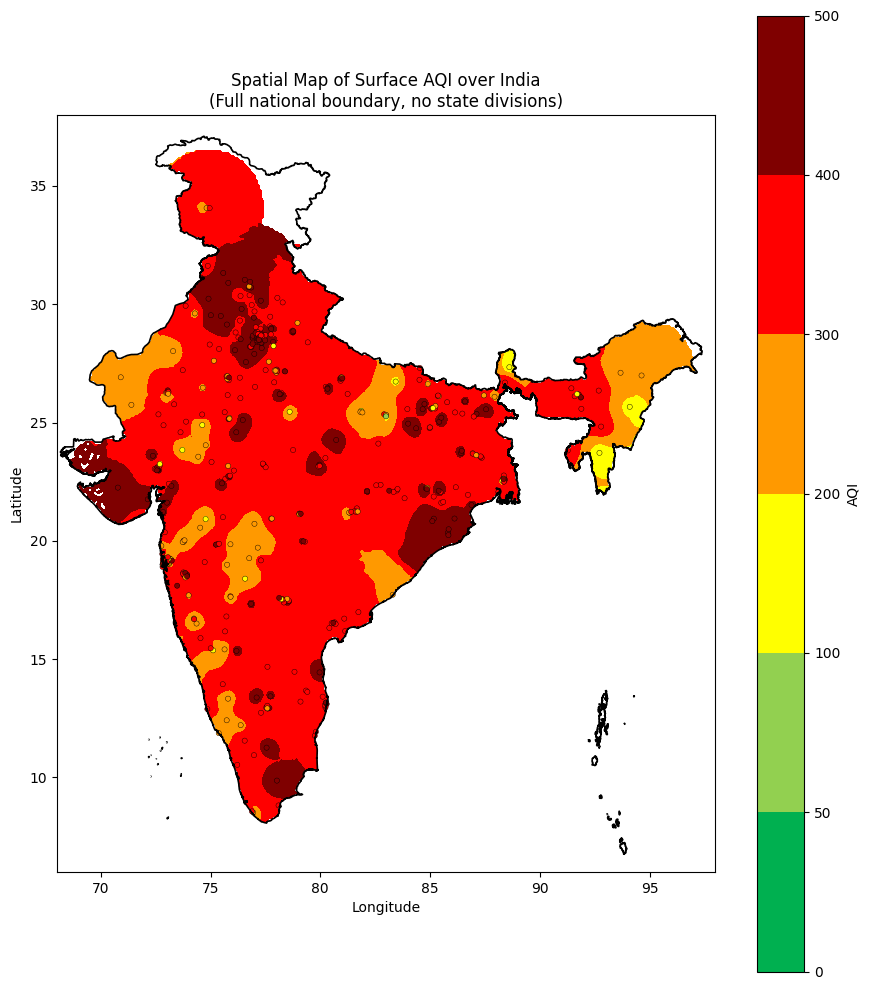

Saved → spatial_aqi_map_full_india.png


In [59]:
# Public India boundary (full country, single dissolved polygon)
india_url = "https://raw.githubusercontent.com/datameet/maps/master/Country/india-composite.geojson"
india = gpd.read_file(india_url).to_crs(epsg=4326)
india_outline = india.dissolve().boundary   # one outer line, no state divisions

# Reuse grid_lon_mesh, grid_lat_mesh, grid_aqi from Part 5 (cell 46)
mask_inside = contains(india.unary_union, grid_lon_mesh.ravel(), grid_lat_mesh.ravel())
mask_inside = mask_inside.reshape(grid_lon_mesh.shape)

grid_aqi_country = np.where(mask_inside, grid_aqi, np.nan)
grid_aqi_country_masked = np.ma.masked_invalid(grid_aqi_country)

fig, ax = plt.subplots(figsize=(9, 10))

levels = [0, 50, 100, 200, 300, 400, 500]
colors = ["#00b050", "#92d050", "#ffff00", "#ff9900", "#ff0000", "#7f0000"]
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = plt.matplotlib.colors.BoundaryNorm(levels, cmap.N)

mesh = ax.contourf(grid_lon_mesh, grid_lat_mesh, grid_aqi_country_masked,
                    levels=levels, colors=colors, norm=norm)

india_outline.plot(ax=ax, color="black", linewidth=1.2)   # national border only
ax.scatter(lons, lats, c=aqis, cmap=cmap, norm=norm,
           s=14, edgecolor="black", linewidth=0.3)

ax.set_xlim(68, 98)
ax.set_ylim(6, 38)
ax.set_title("Spatial Map of Surface AQI over India\n(Full national boundary, no state divisions)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = fig.colorbar(mesh, ax=ax, ticks=levels)
cbar.set_label("AQI")

plt.tight_layout()
plt.savefig("spatial_aqi_map_full_india.png", dpi=150)
plt.show()
print("Saved → spatial_aqi_map_full_india.png")